<a href="https://colab.research.google.com/github/hellenppassos-beep/Primeira-Avaliacao-Fundamentos-Computacionais/blob/main/PROVA_2_FCE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
#Aqui crio a classe que contêm os parâmetros fornecidos do reator

from dataclasses import dataclass
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

@dataclass

class Parametros:
  VelocidadeMaximaReferencia: float
  ConstanteMichaelis: float
  EnergiaAtivacao: float
  ConstanteGases: float
  TemperaturaReferencia: float

In [110]:

#Local onde se calcula a velocidade máxima, resultado que será utilizado posteriormente

def CalculadoraVelocidade(T,Dados):

  Vref= Dados.VelocidadeMaximaReferencia
  Tref = Dados.TemperaturaReferencia
  Km = Dados.ConstanteMichaelis
  Ea = Dados.EnergiaAtivacao
  R = Dados.ConstanteGases

  Vmax = Vref*np.exp((-Ea/R) * ((1/T)-(1/Tref)))
  return Vmax

In [111]:
#Local onde se calcula a EDO utilizando o resultado de Vmax
def ModeloBioreator(t, S, VmaxCalculado, Dados):

  dSdt = - VmaxCalculado * (S / (Dados.ConstanteMichaelis + S))
  return [dSdt]

In [112]:
# Local onde se calcula a Concentracao no tempo t chamando ambas funções criadas
def SimuladorBioreator(S0, T, Dados, IntervaloTempo):

  VmaxCalculado = CalculadoraVelocidade(T, Dados)



  t_span = np.array(IntervaloTempo)


  SolucaoConcentracao = solve_ivp(ModeloBioreator, t_span, [S0],
                                  args=(VmaxCalculado, Dados), method="RK45")


  return SolucaoConcentracao.t, SolucaoConcentracao.y[0]

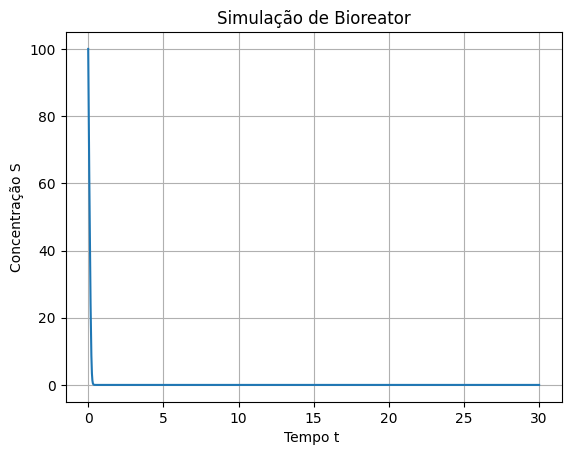

In [116]:
# Alimentação dos dados, chamada dos cálculos e plot do gráfico
Dados = Parametros( VelocidadeMaximaReferencia = 5.0, ConstanteMichaelis = 20.0,
                   EnergiaAtivacao = 30000, ConstanteGases = 8.314, TemperaturaReferencia = 298.15
)
T = 500.0
S0 = 100

IntervaloTempo = [0,30]

t_sol, S_sol = SimuladorBioreator(S0, T, Dados, IntervaloTempo)


plt.plot(t_sol, S_sol)
plt.xlabel('Tempo t ')
plt.ylabel('Concentração S')
plt.title('Simulação de Bioreator')
plt.grid(True)
plt.show()